# Linear Discriminant Analysis (LDA)

We learned in class that PCA serves well in terms of lowering the dimensionality of the data.
However, it does not aim to maximize the classification accuracy. PCA actually aims to retain the
most information in the lowest possible subspace (as shown from our reconstruction experiment).
PCA is also an unsupervised algorithm. We did not use any class information when we compute
for PCA. On the other hand, LDA takes the class labels as inputs and aim to find the projection
that maximize the separability between the classes.
LDA is usually used in conjunction with PCA. We first project using PCA to a lower dimensionality
then use LDA to project to a subspace that better separates the class.
Assuming everything is already in the PCA subspace, to find the LDA projections, we first need to
find the between class scatter, $S_B$ , and the within class scatter, $S_W$ . Between class scatter
represents the spread between two classes. In class, for the two classes example, it is defined as
the distance between the means of class 1 and class 2 as shown below:

In [17]:
from skimage import img_as_float
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import scipy.io
import numpy as np
import numpy as np

data = scipy.io.loadmat('facedata.mat')


### **Part 1**

In order to assure that $S_W$ is invertible we need to make sure that $S_W$ is full rank. How
many PCA dimensions do we need to keep in order for $S_W$ to be full rank?

In [4]:
num_people = 40
num_train_pose = 3
num_test_pose = 7
N = num_people * num_train_pose
D = 56 * 46

xf_train = {}
xf_test = {}
for people in range(num_people):
    for pose in range(num_train_pose):
        xf_train[people, pose] = img_as_float(data['facedata'][people, pose])

for people in range(num_people):
    for pose in range(num_test_pose):
        xf_test[people, pose] = img_as_float(data['facedata'][people, pose])

In [26]:
xf_train_np = np.zeros((num_people, num_train_pose, 56, 46))
xf_test_np  = np.zeros((num_people, num_test_pose, 56, 46))

for people in range(num_people):
    for pose in range(num_train_pose):
        xf_train_np[people, pose] = img_as_float(data['facedata'][people, pose])

for people in range(num_people):
    for pose in range(num_test_pose):
        xf_test_np[people, pose] = img_as_float(data['facedata'][people, num_train_pose + pose])
        
train_flat = xf_train_np.reshape(num_people, num_train_pose, -1)
test_flat = xf_test_np.reshape(num_people, num_test_pose, -1)
print(f"train shape: {train_flat.shape} | test shape: {test_flat.shape}")

train shape: (40, 3, 2576) | test shape: (40, 7, 2576)


In [28]:
# We combine people and poses into one dimension for easier iteration
Sw = np.zeros((D, D))
Sb = np.zeros((D, D))
global_mean = np.mean(train_flat, axis=(0, 1)) # Shape (D,)

for i in range(num_people):
    person_images = train_flat[i] 
    class_mean = np.mean(person_images, axis=0)
    for j in range(num_train_pose):
        diff = (person_images[j] - class_mean).reshape(-1, 1) # Column vector (D, 1)
        Sw += diff @ diff.T
        
    # --- Calculate Sb (Between-class scatter) ---
    mean_diff = (class_mean - global_mean).reshape(-1, 1) # Column vector (D, 1)
    Sb += num_train_pose * (mean_diff @ mean_diff.T)

print(f"Sw shape: {Sw.shape} | Sb shape: {Sb.shape}") # Should be (2576, 2576)

Sw shape: (2576, 2576) | Sb shape: (2576, 2576)


In [30]:
rank_Sw = np.linalg.matrix_rank(Sw)
rank_Sb = np.linalg.matrix_rank(Sb)

print(f"The rank of Sw is: {rank_Sw}")
print(f"The dimension of Sw is: {Sw.shape[0]}")
print(f"The rank of Sb is: {rank_Sb}")
print(f"The dimension of Sb is: {Sb.shape[0]}")

if rank_Sw < Sw.shape[0]:
    print("Matrix is Singular (Not invertible!)")

The rank of Sw is: 80
The dimension of Sw is: 2576
The rank of Sb is: 39
The dimension of Sb is: 2576
Matrix is Singular (Not invertible!)


#### **Answer**
- $S_W$ is Not invertible, it has only rank 80, which not full rank.
- the number of PCA dimensions $k$ must satisfy:
$$k \le N - N_c$$
- Total Training Samples ($N$): 120 (40 people $\times$ 3 poses)
- Number of Classes ($N_c$): 40

We need at **`keep 80 or fewer PCA dimensions.`**

### **Part 2**

In [ ]:
# Build data matrix: one row = one image
X = np.zeros((N, D))

idx = 0
for i in range(num_people):
    for j in range(num_train_pose):
        X[idx] = xf_train_np[i, j].reshape(-1)
        idx += 1
# Global mean face
mean_face = np.mean(X, axis=0)   # shape (D,)
# Center all images
x_center = X - mean_face       # shape (N, D)
# Covariance matrix
cov = (x_center.T @ x_center) / (N - 1)   # shape (D, D)

Calculating Gram Matrix


In [34]:
G = x_center @ x_center.T    # shape (N, N)
G_eigenvalues, G_eigenvectors = np.linalg.eigh(G)

# sort in descending order
idx = np.argsort(G_eigenvalues)[::-1]
G_eigenvalues = G_eigenvalues[idx]
G_eigenvectors = G_eigenvectors[:, idx]

Calculating Covariance eigenvector

In [91]:
components = 80
cov_eigenvectors = x_center.T @ G_eigenvectors[:, :components]
cov_eigenvectors = cov_eigenvectors/np.linalg.norm(cov_eigenvectors, axis=0)

In [92]:
train_pca = np.zeros((num_people, num_train_pose, components))
test_pca = np.zeros((num_people, num_test_pose, components))

for i in range(num_people):
    for j in range(num_train_pose):
        x = xf_train_np[i, j].reshape(-1)
        train_pca[i, j] = cov_eigenvectors.T @ (x - mean_face)

for i in range(num_people):
    for j in range(num_test_pose):
        x = xf_test_np[i, j].reshape(-1)
        test_pca[i, j] = cov_eigenvectors.T @ (x - mean_face)

In [93]:
Sw = np.zeros((components, components))
Sb = np.zeros((components, components))

# Correct global mean (axis=(0,1) collapses people and poses)
global_mean_pca = np.mean(train_pca, axis=(0, 1))

for i in range(num_people):
    # Select all poses for person i: shape (3, 80)
    person_images = train_pca[i] 
    
    # Class mean for person i: shape (80,)
    class_mean = np.mean(person_images, axis=0)
    
    # Sw: Sum of squared differences within this class
    for j in range(num_train_pose):
        diff = (person_images[j] - class_mean).reshape(-1, 1)
        Sw += diff @ diff.T
        
    # Sb: Difference between class mean and global mean
    mean_diff = (class_mean - global_mean_pca).reshape(-1, 1)
    Sb += num_train_pose * (mean_diff @ mean_diff.T)

# Solve for LDA Projections
Sw_inv = np.linalg.inv(Sw)
M = Sw_inv @ Sb

# Use eig, not eigh, because M is NOT symmetric
eigenvalues, eigenvectors = np.linalg.eig(M)

# Sort eigenvectors by eigenvalues (descending)
idx = np.argsort(eigenvalues.real)[::-1]
lda_projections = eigenvectors[:, idx].real

In [ ]:
sym = np.array_equal(M, (M).T)
print(f"Is Sw_inv @ Sb symmetric? {sym}")
# print(f"Eigen output from np.linalg.eigh: {np.linalg.eigh(M)}")

Is Sw_inv @ Sb symmetric? False
Eigen output from np.linalg.eigh: EighResult(eigenvalues=array([-9.54886662e+07, -5.84233009e+06, -2.50093147e+06, -1.20098756e+06,
       -5.99900113e+05, -4.76828051e+05, -3.15043786e+05, -2.43646084e+05,
       -2.03701889e+05, -1.49387198e+05, -1.32962064e+05, -9.48394310e+04,
       -6.28339263e+04, -5.03161185e+04, -4.53836182e+04, -3.64242568e+04,
       -3.07605747e+04, -2.69201752e+04, -2.62076361e+04, -2.56441121e+04,
       -2.49235363e+04, -2.14934709e+04, -1.44254413e+04, -1.26391469e+04,
       -1.11572879e+04, -1.06263959e+04, -1.01927656e+04, -9.79829987e+03,
       -9.38459617e+03, -7.65725994e+03, -6.09443640e+03, -5.46970531e+03,
       -5.36706823e+03, -5.23823130e+03, -4.43881050e+03, -4.25346694e+03,
       -3.78961815e+03, -2.57978007e+03, -2.29197842e+03, -2.06429092e+03,
       -2.04073018e+03, -1.53768392e+03, -1.49521776e+03, -1.44211153e+03,
       -1.36897913e+03, -1.26559906e+03, -1.22107974e+03, -1.17447454e+03,
       -1.1

#### **Answer**
- Is $S_w^{−1}S_B$ symmetric? 
    - **`No`**. The product of two symmetric matrices is not necessarily symmetric.
- Can we still use `numpy.linalg.eigh`?
    - **`No`**. We must use `np.linalg.eig` because the matrix is non-symmetric.
- How many non-zero eigenvalues are there?
    - There are **`39`** ($N_c - 1$). Even though the matrices are $80 \times 80$, the rank of $S_B$ limits the non-zero eigenvalues to one less than the number of classes.

### **Part 4**

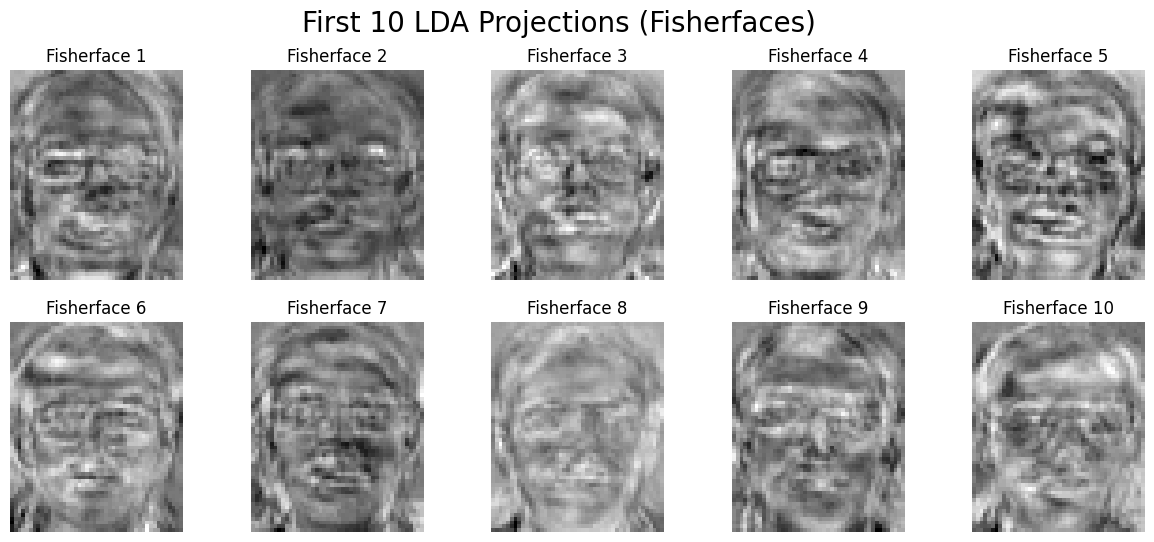

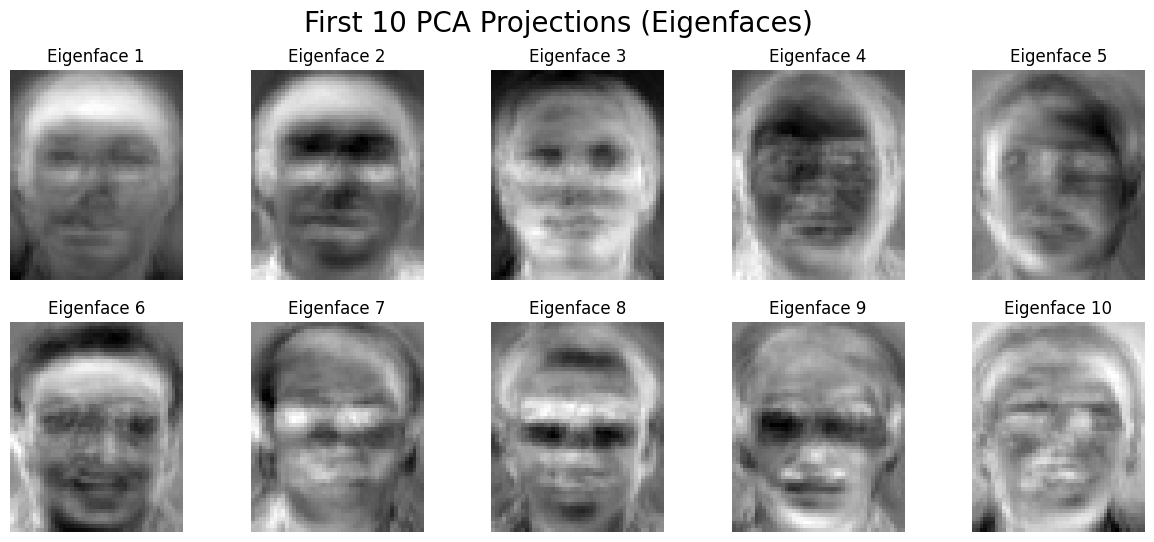

In [97]:

fisherfaces = cov_eigenvectors @ lda_projections[:, :] # (2576, 80) @ (80, 80) -> (2576, 80)

# 3. Plot the first 10 Fisherfaces
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # Reshape the vector to original image dimensions
    plt.imshow(fisherfaces[:, i].reshape(56, 46), cmap='gray')
    plt.title(f"Fisherface {i+1}")
    plt.axis('off')
plt.suptitle("First 10 LDA Projections (Fisherfaces)",fontsize=20)
plt.show()

eigenface = cov_eigenvectors[:, :components].T.reshape(components, 56, 46)
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # Reshape the vector to original image dimensions
    plt.imshow(eigenface[i], cmap='gray')
    plt.title(f"Eigenface {i+1}")
    plt.axis('off')
plt.suptitle("First 10 PCA Projections (Eigenfaces)",fontsize=20)
plt.show()

### **Part 5**

In [95]:
def face_verification(similarity, t, num_people=40, num_test_pose=7):
    """
    similarity: shape (num_test_images, num_people, num_train_pose)
    t: threshold
    num_people: number of people
    num_test_pose: number of test images per person

    Returns TP, TN, FP, FN, TPR, FAR
    """
    TP = TN = FP = FN = 0

    num_test_images = similarity.shape[0]

    for image in range(num_test_images):
        true_person = image // num_test_pose

        for check_person in range(num_people):
            min_dist = np.min(similarity[image, check_person, :])

            pred_same = (min_dist < t)
            actual_same = (check_person == true_person)

            if pred_same and actual_same:
                TP += 1
            elif pred_same and not actual_same:
                FP += 1
            elif not pred_same and actual_same:
                FN += 1
            else:
                TN += 1

    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    FAR = FP / (FP + TN) if (FP + TN) > 0 else 0

    return {
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "TPR": TPR,
        "FAR": FAR
    }
    
def similarity_matrix(T,D):
    """ Calculating the simlarity of matrix T and D with euclidean distance """
    # A = np.sqrt(np.sum((T - D)**2))
    A = np.linalg.norm(T - D)
    return A

$$\hat{x}_{raw} = W_{pca} \cdot (W_{lda} \cdot y) + \mu$$

In [103]:
num_fisher = num_people - 1 # 39

# Create projections
# train_pca shape: (40, 3, 80) -> (120, 80)
# lda_projections shape: (80, 80) -> (80, 39)
train_fisher = train_pca.reshape(-1, components) @ lda_projections[:, :num_fisher] # (120, 39)
test_fisher = test_pca.reshape(-1, components) @ lda_projections[:, :num_fisher]   # (280, 39)

train_fisher_reshaped = train_fisher.reshape(num_people, num_train_pose, num_fisher) # (40, 3, 39)
test_fisher_reshaped = test_fisher.reshape(num_people, num_test_pose, num_fisher) # (40, 7, 39)


In [104]:
sim_fisher = np.zeros((num_people * num_test_pose, num_people, num_train_pose))
for i in range(num_people * num_test_pose):
    test_vec = test_fisher[i] 
    
    for p in range(num_people):
        for pose in range(num_train_pose):
            train_vec = train_fisher_reshaped[p, pose]
            sim_fisher[i, p, pose] = np.linalg.norm(test_vec - train_vec)

Closest point:
FAR = 0.07087912087912088
TPR = 0.9285714285714286
Threshold = 3.6636636636636637


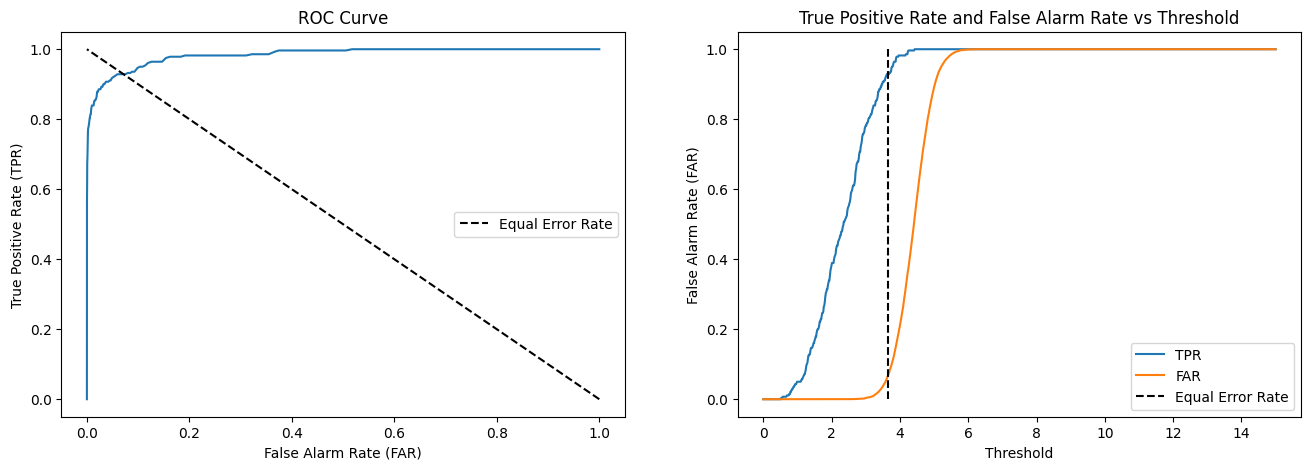

In [109]:
num_thresholds = 1000
thresholds = np.linspace(0, 15, num_thresholds)
tpr_13 = np.array([])
far_13 = np.array([])


for i, t in enumerate(thresholds):
    result = face_verification(similarity=sim_fisher, t=t)

    tpr_13 = np.append(tpr_13, result['TPR'])
    far_13 = np.append(far_13, result['FAR'])

plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
plt.plot(far_13, tpr_13)
plt.plot([1, 0], [0, 1], 'k--', label='Equal Error Rate')
plt.title('ROC Curve')
plt.xlabel('False Alarm Rate (FAR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend()

dist_to_line = np.abs(tpr_13 - (1 - far_13)) / np.sqrt(2)
idx = np.argmin(dist_to_line)

plt.subplot(1, 2, 2)
plt.plot(thresholds, tpr_13, label='TPR')
plt.plot(thresholds, far_13, label='FAR')
plt.plot([thresholds[idx], thresholds[idx]], [0, 1], 'k--', label='Equal Error Rate')
plt.title('True Positive Rate and False Alarm Rate vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('False Alarm Rate (FAR)')
plt.legend()

print("Closest point:")
print("FAR =", far_13[idx])
print("TPR =", tpr_13[idx])
print("Threshold =", thresholds[idx])

In [110]:
result = face_verification(similarity=sim_fisher, t=3.6636636636636637)
print(f"True Positive Rate: {result['TPR']}")
print(f"False Alarm Rate: {result['FAR']}")
print(f"TP: {result['TP']}, TN: {result['TN']}, FP: {result['FP']}, FN: {result['FN']}")
print(f"Result: {result}")

True Positive Rate: 0.9285714285714286
False Alarm Rate: 0.07087912087912088
TP: 260, TN: 10146, FP: 774, FN: 20
Result: {'TP': 260, 'TN': 10146, 'FP': 774, 'FN': 20, 'TPR': 0.9285714285714286, 'FAR': 0.07087912087912088}
